In [40]:
# 7 basic questionsh
import numpy as np
import pandas as pd

In [41]:
# Data size
df = pd.read_csv("Titanic-Dataset.csv")

In [42]:
df.shape

(891, 12)

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [45]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [46]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [47]:
df.duplicated().sum()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
df_num = df.drop(['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1) # Numerical fields only
df_num.corr()['Survived']

Survived    1.000000
Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Name: Survived, dtype: float64

# Univariate EDA

In [49]:
# Univariate EDA
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Embarked', ylabel='count'>

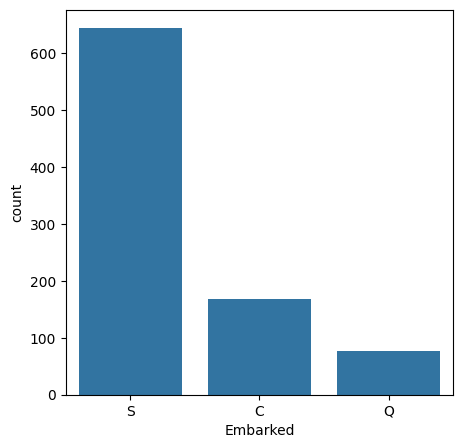

In [50]:
plt.figure(figsize=(5,5))
sns.countplot(df, x=df['Embarked'])

<Axes: ylabel='count'>

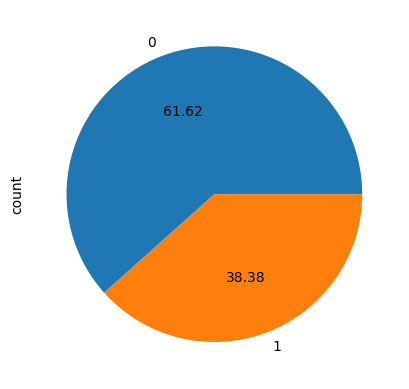

In [51]:
df['Survived'].value_counts()
df['Survived'].value_counts().plot(kind='pie', autopct='%.2f')

(array([496., 191.,  45.,  45.,  48.,  13.,  11.,  11.,   9.,   2.,   0.,
          0.,   5.,   4.,   2.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  17.07764,  34.15528,  51.23292,  68.31056,  85.3882 ,
        102.46584, 119.54348, 136.62112, 153.69876, 170.7764 , 187.85404,
        204.93168, 222.00932, 239.08696, 256.1646 , 273.24224, 290.31988,
        307.39752, 324.47516, 341.5528 , 358.63044, 375.70808, 392.78572,
        409.86336, 426.941  , 444.01864, 461.09628, 478.17392, 495.25156,
        512.3292 ]),
 <BarContainer object of 30 artists>)

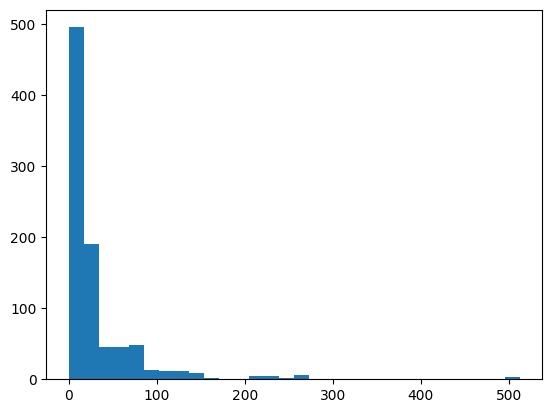

In [52]:
plt.hist(df['Fare'], bins=30)

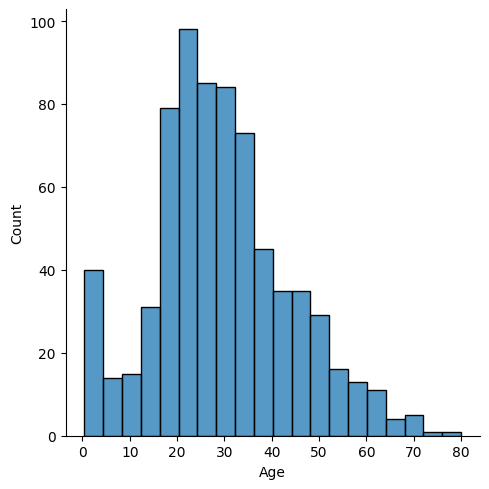

In [53]:
sns.displot(df['Age'])

<Axes: ylabel='Age'>

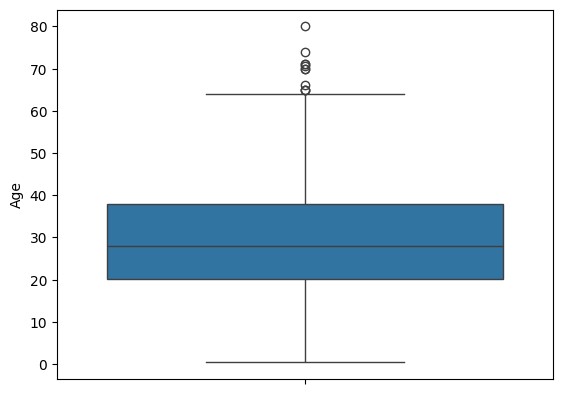

In [54]:
sns.boxplot(df['Age'])

<Axes: xlabel='Age', ylabel='Density'>

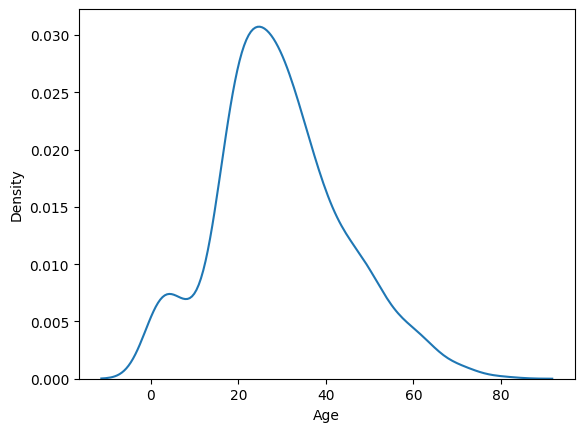

In [55]:
sns.kdeplot(df['Age'])

In [56]:
df['Age'].skew()

0.38910778230082704

# Multivariate EDA

In [62]:
# Fix macOS Python SSL cert errors for HTTPS downloads (e.g., seaborn.load_dataset)
import os
import sys
import subprocess

try:
    import certifi
except Exception:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "certifi"])
        import certifi
    except Exception as exc:
        certifi = None
        print("Could not install/import certifi:", exc)

if certifi is not None:
    # Ensure urllib/ssl can locate a CA bundle
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
    print("Using CA bundle:", os.environ["SSL_CERT_FILE"])
else:
    print("If you're using python.org macOS Python, run 'Install Certificates.command' for your Python install.")


Using CA bundle: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/certifi/cacert.pem


In [76]:
tips = sns.load_dataset('tips') # a new dataset
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

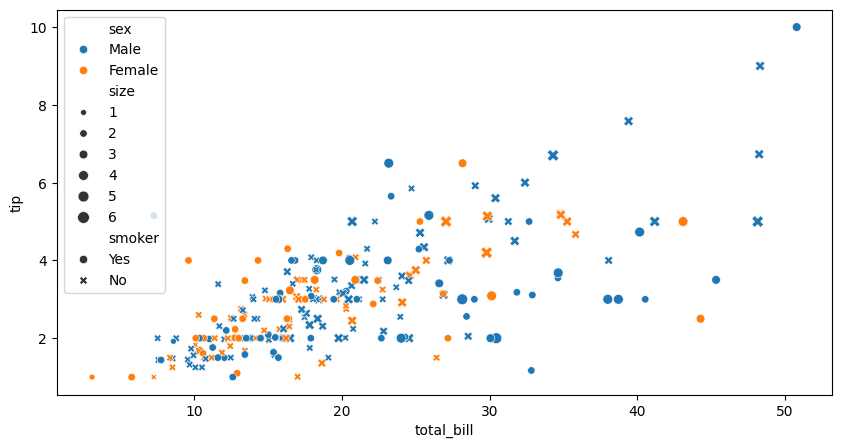

In [71]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', style='smoker', size='size')

<Axes: xlabel='day', ylabel='total_bill'>

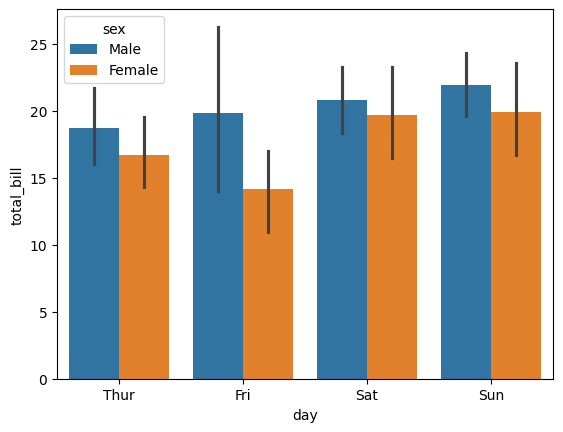

In [77]:
sns.barplot(data=tips, x='day', y='total_bill', hue='sex')

<Axes: xlabel='Sex', ylabel='Age'>

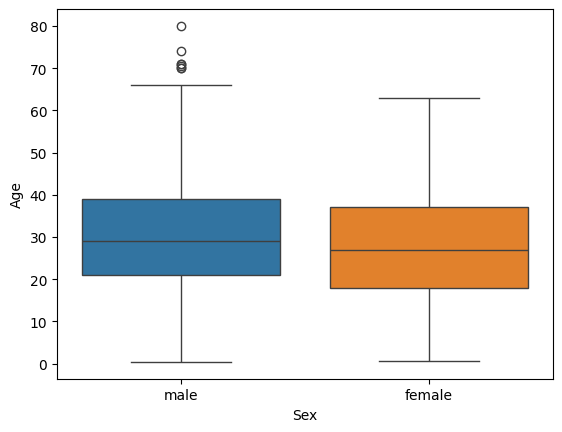

In [79]:
sns.boxplot(data=df, x='Sex', y='Age')

In [90]:
y1 = df[df['Survived']==0]
y2 = df[df['Survived']!= 0]

sns.kdeplot(df['Age'], y1, label='Not Survived', shade=True)
sns.kdeplot(df['Age'], y2, label='Survived', shade=True)

TypeError: kdeplot() takes from 0 to 1 positional arguments but 2 were given

In [89]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [ ]:
sns.heatmap(df)

In [93]:
df_flights = sns.load_dataset('flights') # a new dataset
df_flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [94]:
df_flights.groupby('month').sum()['passengers']

/var/folders/7v/x365pgqd6_d1r94p70v20y380000gn/T/ipykernel_91339/119041656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_flights.groupby('month').sum()['passengers']


month
Jan    2901
Feb    2820
Mar    3242
Apr    3205
May    3262
Jun    3740
Jul    4216
Aug    4213
Sep    3629
Oct    3199
Nov    2794
Dec    3142
Name: passengers, dtype: int64

In [ ]:
flights_wide = df_flights[]


In [96]:
df_iris = sns.load_dataset('iris')
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


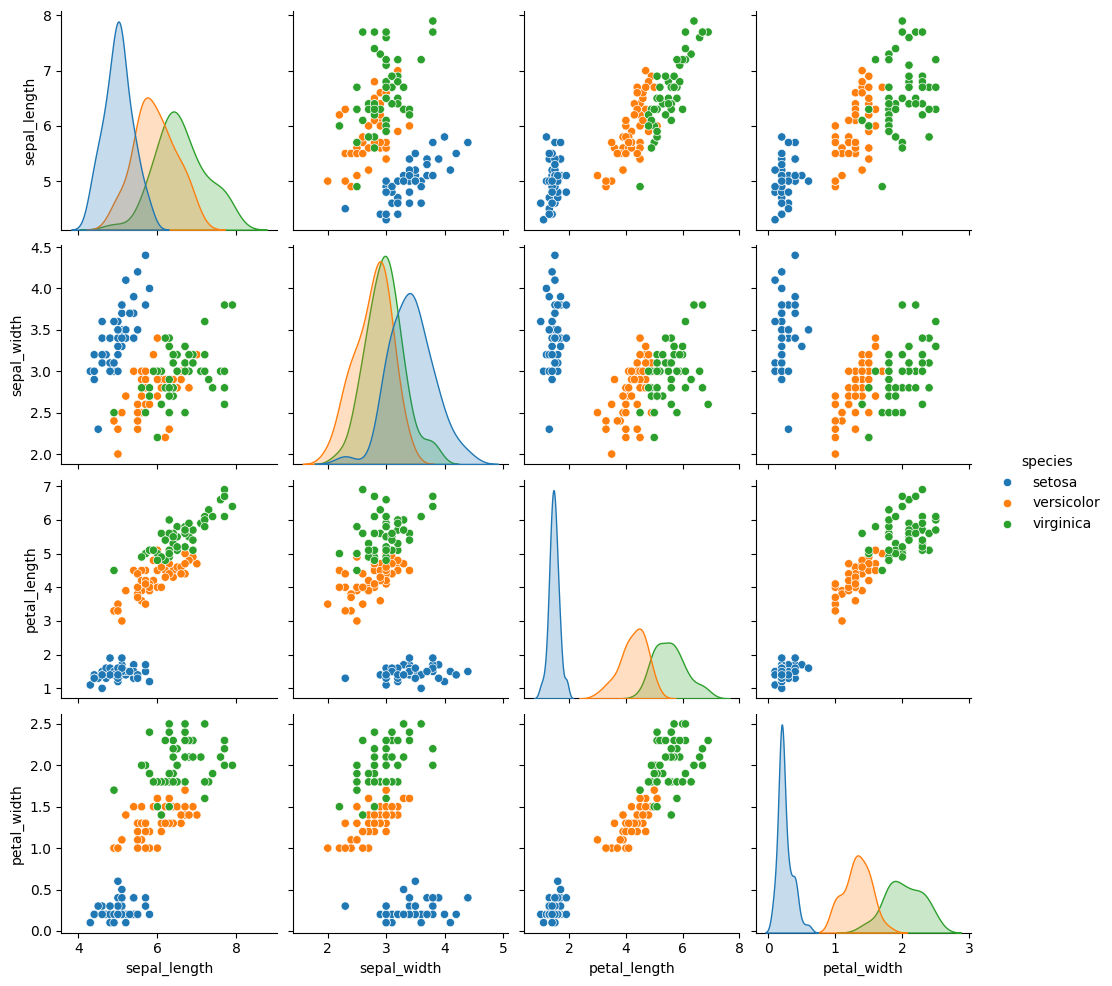

In [97]:
sns.pairplot(df_iris, hue='species')